# WRF U-Net Downscaling: Inference

This notebook loads a trained checkpoint and uses it to predict fine-grid fields for a selected year.

The preprocessing details are explained in `WRF_Data_Preprocessing_Colab.ipynb`. Here we reuse `WRFNPZDataset` so inference matches training.


## 1. Set Up Paths

Run this notebook from inside the `dl_downscaling_teaching/backup` directory's parent teaching folder if you use this archived workflow. The checkpoint lives in `outputs`; predicted NPZ files are saved in `data/wrf_npz_predicted`.


In [ ]:
import config as cfg

print("Teaching directory:", cfg.PROJECT_DIR)
print("Data directory:    ", cfg.DATA_DIR)
print("Predicted data:    ", f"{cfg.DATA_DIR}/wrf_npz_predicted")


## 2. Import Libraries

Inference uses the same model class and dataset class as training.


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

from Network import UNet
from dataset import WRFNPZDataset
from utils import load_channel_stats, plot_saved_prediction, save_predicted_year_npz

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)


/Users/jackychung/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 3. Choose Years And Checkpoint

Use the best checkpoint saved by the training notebook.


In [ ]:
print("Inference years:   ", cfg.INFERENCE_YEARS)
print("Batch size:        ", cfg.BATCH_SIZE)
print("Static file:       ", cfg.STATIC_NPZ_PATH)
print("Checkpoint:        ", cfg.CHECKPOINT_PATH)
print("Inference outputs: ", f"{cfg.DATA_DIR}/wrf_npz_predicted")


## 4. Load Normalization Statistics

Inference must use the same variables and normalization as training.


In [4]:
raw_mean, raw_std = load_channel_stats(cfg.RAW_STATS, cfg.DL_OUT_SINGLE_LAYER_PARAMS)
residual_mean, residual_std = load_channel_stats(
    cfg.RESIDUAL_STATS,
    cfg.DL_OUT_SINGLE_LAYER_PARAMS,
)

print("Weather variables:", list(cfg.DL_OUT_SINGLE_LAYER_PARAMS))
print("Static variables: ", list(cfg.CONSTANT_PARAMS))


Weather variables: ['T2', 'TD2', 'MSLP', 'U10', 'V10', 'LN_ACC_6H_PRECIP']
Static variables:  ['LSM', 'HGT']


## 5. Load The Trained Model

The checkpoint stores the learned weights. It may also store the small U-Net settings used during training.


In [5]:
def load_trained_model(checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location=DEVICE)

    model = UNet(
        img_resolution=cfg.HIGH_RES_SHP,
        in_channels=len(cfg.DL_OUT_SINGLE_LAYER_PARAMS) + len(cfg.CONSTANT_PARAMS),
        out_channels=len(cfg.DL_OUT_SINGLE_LAYER_PARAMS),
        label_dim=4,
        use_diffuse=False,
        **cfg.MODEL_KWARGS,
    )
    model = model.to(DEVICE)
    model.load_state_dict(state_dict)
    model.eval()
    return model


model = load_trained_model(cfg.CHECKPOINT_PATH)
print("Loaded checkpoint:", cfg.CHECKPOINT_PATH)


Loaded checkpoint: /Users/jackychung/Documents/codex-test/fyp-teaching/dl_downscaling_teaching/outputs/unet_npz_best.pt


## 6. Predict One Dataset

The model predicts normalized residuals. The dataset helper converts those residuals back to physical units and adds them to the coarse field.


In [6]:
def predict_dataset(model, dataset, batch_size):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    coarse_batches = []
    fine_batches = []
    predicted_batches = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Inference", leave=False):
            inputs = batch["inputs"].to(DEVICE)
            condition = batch["condition"].to(DEVICE)

            residual_prediction = model(inputs, class_labels=condition)
            residual_prediction = residual_prediction.cpu()

            predicted_fine = dataset.residual_to_fine(residual_prediction, batch["coarse"])

            coarse_batches.append(batch["coarse"])
            fine_batches.append(batch["fine"])
            predicted_batches.append(predicted_fine)

    coarse = torch.cat(coarse_batches, dim=0).numpy().astype(np.float32)
    fine = torch.cat(fine_batches, dim=0).numpy().astype(np.float32)
    predicted = torch.cat(predicted_batches, dim=0).numpy().astype(np.float32)

    return coarse, fine, predicted


## 7. Run Inference Year By Year

Saving separate files by year keeps the inference outputs organized.


In [ ]:
all_outputs = {}

for year in cfg.INFERENCE_YEARS:
    dataset = WRFNPZDataset(
        years=[year],
        data_dir=cfg.DATA_DIR,
        static_npz_path=cfg.STATIC_NPZ_PATH,
        raw_mean=raw_mean,
        raw_std=raw_std,
        residual_mean=residual_mean,
        residual_std=residual_std,
        output_shape=cfg.HIGH_RES_SHP,
    )

    coarse, fine, predicted = predict_dataset(model, dataset, cfg.BATCH_SIZE)
    saved_path = save_predicted_year_npz(cfg.DATA_DIR, year, dataset, predicted)

    all_outputs[year] = {
        "coarse": coarse,
        "fine": fine,
        "predicted": predicted,
        "saved_path": saved_path,
    }

    print("Year", year)
    print("  coarse shape:   ", coarse.shape)
    print("  fine shape:     ", fine.shape)
    print("  predicted shape:", predicted.shape)

    print("  saved", saved_path)


## 8. Visualize One Result

Plot one saved timestep to compare the coarse input, model prediction, and fine target.


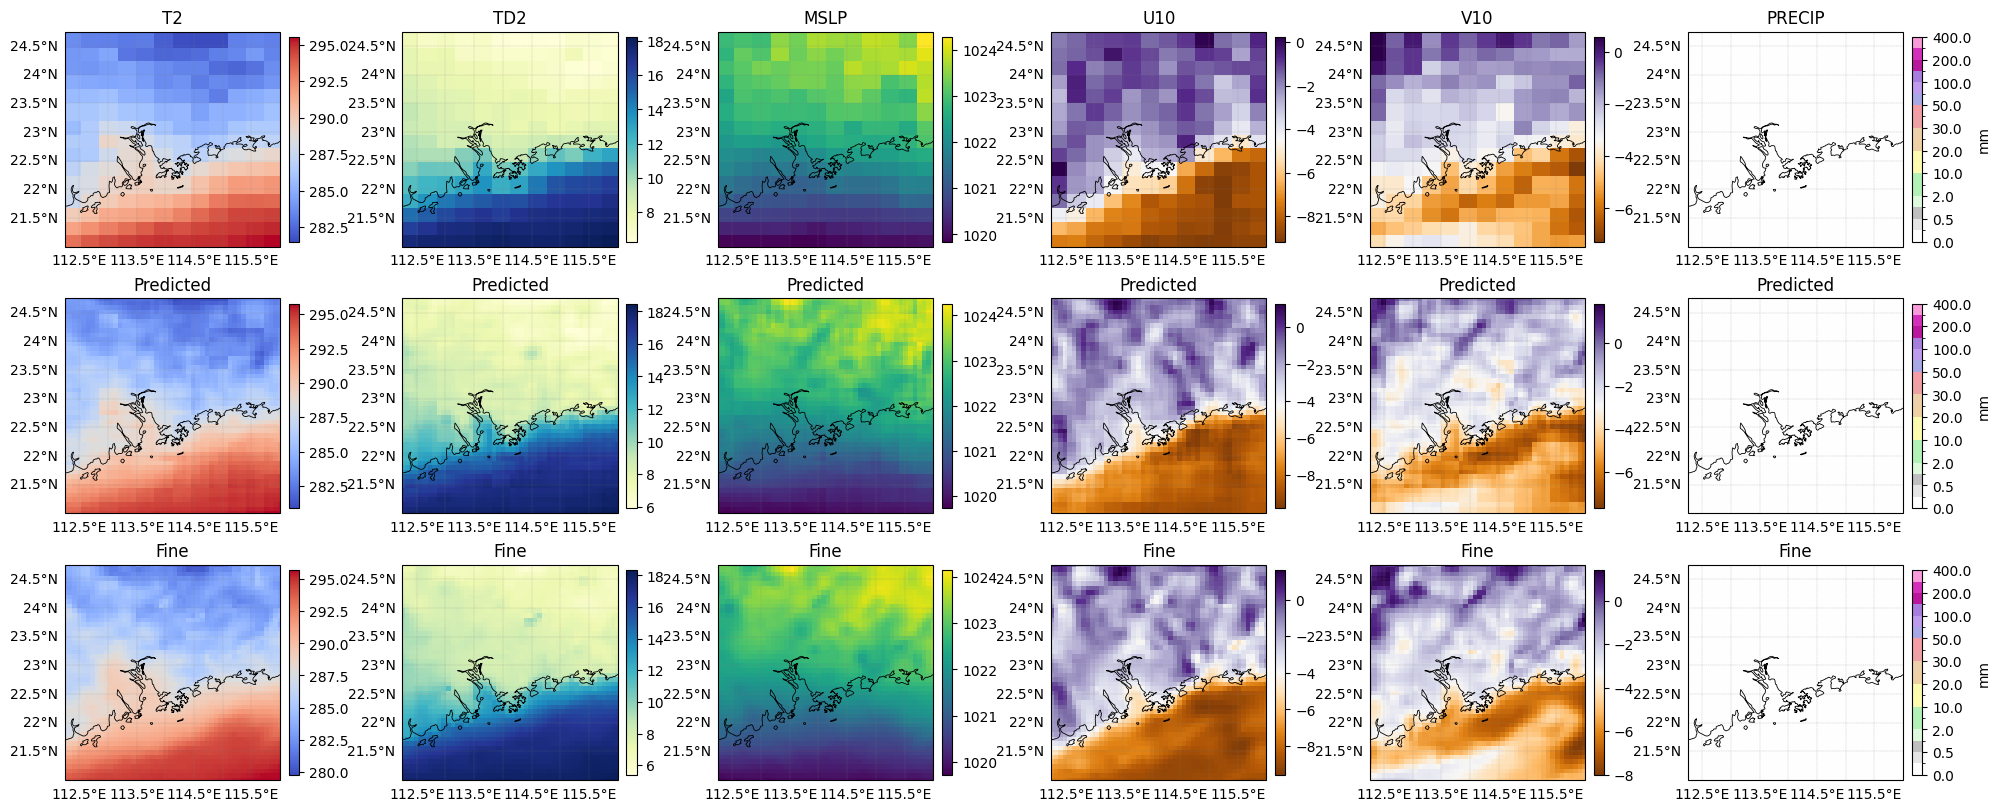

In [8]:
first_year = cfg.INFERENCE_YEARS[0]
fig = plot_saved_prediction(all_outputs, cfg.DL_OUT_SINGLE_LAYER_PARAMS, first_year, index=0)
display(fig)
plt.close(fig)
